# Convolutional Neural Networks


We have learned about how to structure the *back* of our neural networks to be capable of regression or classification.  In addition, we've become comfortable with what we call *dense layers*, where a layer of linear nodes with nonlinear activation functions all connect to every node on the next layer.

It turns out there are other kinds of layers which are more suitable for
specific kinds of data.  This is particularly the case when dealing with
*images* and *language*.  In this class, we're going to look at images.

You may recall that we earlier did an in-class demonstration of the classification of MNIST digits.  In doing this, we took this nice 28x28 image, and flattened it into a single row of length 784.  This was kind of crazy!  What matters for image recognition is the relationship of different pixels to each other, and when we just flatten them, we destroy that relationship (ie, the network has to learn which pixels are adjacent to other pixels, and that that is relevant to its task).

A Convolutional layer is meant to extract meaningful information from 2D blocks of images, rather than looking at the picture as a single row of pixel values.

To understand a convolutional layer, you have to understand a convolution.

Suppose we have this 5x5 black-and-white picture, with these pixel values, and this *filter* (sometimes aka a *kernel*) which is a 2x2 block of numbers.

![](conv1.png)

When we apply this filter to a spot in the image, we do a dot product between the corresponding values of the image and the filter.

![](conv2.png)

In this case, there are sixteen possible 2x2 portions of the image where we could put this filter.  A *convolution* is when we calculate all sixteen of these values, therefore sliding the filter across all possible locations on the image, and calculating this dot product.

![](conv3.png)

![](conv4.png)

![](conv5.png)

Recall that if a dot product between two vectors is high, this means the cosine of the angle between the two vectors is high, meaning the angle is small. So, a large dot product implies the filter and portion of the image are similar.  Convolving a filter across an image is a way of comparing the filter to every part of the image.

A convolutional layer convolves one or more filters across the image, outputting a grid of dot product values for every filter.  This allows the network to see that the image looks like this filter where the values are high, and not where the dot products are small.

Often, a convolutional layer is paired with a nonlinear activation function (like a ReLU), and then fed into a Pooling layer.  The idea behind a pooling layer is that images don't change too much from pixel to pixel, and so we can downsample by taking (for example) 2x2 blocks and only keeping the largest value (this is called a MaxPool).  This shrinks your output grid by half, keeping all this a little more manageable.  Here's the result of applying a MaxPool to the output of the filter above (for the sake of the example, we're skipping the activation function).

![](conv6.png)

So what in here is *learnable*?  It's the values of the filters.  We learn what filters give us the best information about the image to allow for effective regressions/classification/whatever.

A couple terms to know about CNNs:

- The *kernel size* is the size of the filter or kernel.  2x2?  3x3?  5x5?
- A *feature map* is a matrix (or tensor) that captures specific characteristics of the input data, such as patterns, edges, textures, or other relevant features. It is the output of applying a convolutional filter (or kernel) to the input data, like an image (or output of a previous layer). Each filter is trained such that it captures a specific feature (e.g., edges, colors, shapes) in the input data. Applying multiple filters results in and equivalent number of feature maps, each representing different aspects of the input.
- The *stride* is how many pixels to advance before applying the filter again. In the above example, the stride was 1, because we applied it at every possible place - if we had just applied it to every other location, the stride would be 2.
- In order to not cheat the edges and corners, often some *padding* is applied, which is extra rows and columns around the edges to allow the filter to be centered even at locations around the edges.  There are various padding techniques, including just throwing 0s in there, or setting them to the value of the nearest actual pixel.
- The *max pooling* layer is a downsampling function which reduces the spatial dimensions of feature maps, thereby reducing the number of necessary learned parameters of a layer. This reduction in complexity helps both with computational cost and helps the model generalize better by making the feature maps less sensitive to small translations in the input.
- CNN's still typically at least end with a fully connected or dense layer in which the final most complex feature maps learned are combined either for regression, classification, or another purpose.
- *Dropout* is a regularization technique used to prevent overfitting by randomly dropping (i.e., setting to zero) a fraction of the neurons in designated layers during the trainaing process(a predetermined fraction). 
- The final layer often has an activation function like Softmax (for multi-class classification) or Sigmoid (for binary classification).
  
## Code Demo

In [1]:
import numpy as np
import torch.nn as nn
import torch
import torch.optim as optim

In [2]:
with open('mnist.npy','rb') as f:
    pics=np.load(f)
    labels=np.load(f)
print(f'Pics shape: {pics.shape}')
print(f'labels shape: {labels.shape}')

Pics shape: (60000, 28, 28)
labels shape: (60000,)


In past MNIST manipulations, we've turned each data point into a single row of pixel values, getting rid of the 28x28 picture. Here, we're keeping each data point as-is, so we can use our convolutions.

### Our model

Here's a very simple convolutional network. Notice it's made up of two sequences of 2D Convolutions, followed by a ReLU, followed by a MaxPool.

In the first sequence, it take in one channel (because it's merely grayscale - were it a color picture, this would be 3), and produces 16 different convolutional filters, each of which is 5x5. They each "stride" along at every pixel (so the stride is 1), and have a padding of 2. This gives us 16 filters, each of which is outputting a 28x28 grid of values. The maxpool outputs the maximum value for each channel for every 2x2 block, which gives us a 16x14x14 block (14 being half of 28, resulting from the 2x2 max pool).

In the second, it takes in 16 channels (ie, the same number that the previous one outputs), creates 32 channels, is 5x5, with a stride of 1, and a padding of 2. This gives us an output from the Conv2d (and ReLU) of 32x14x14. MaxPool downsamples this to a 32x7x7.

These 32x7x7 values are then flattened into a single vector of length 1568 (32*7*7), and linearly combined into 10 output logits.


In [3]:
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        self.conv1 = nn.Sequential(   # takes in a 1x28x28
            nn.Conv2d(
                in_channels=1,              
                out_channels=16,            
                kernel_size=5,              
                stride=1,                   
                padding=2,                  
            ),                              
            nn.ReLU(),                      
            nn.MaxPool2d(kernel_size=2),    
        ) # outputs a 16x14x14
        self.conv2 = nn.Sequential(  # takes in a 16x14x14
            nn.Conv2d(16, 32, 5, 1, 2),     
            nn.ReLU(),                      
            nn.MaxPool2d(2),                
        ) # outputs a 32x7x7
        self.out = nn.Linear(32 * 7 * 7, 10)
        
    def forward(self, x):
        x = self.conv1(x) # 16x14x14
        x = self.conv2(x) # 32x7x7
        x = x.view(x.size(0), -1) # flatten this into a single vector of size 32*7*7=1568
        output = self.out(x) # combine into 10 output logits
        return output

### Train/test split, Datasets, Dataloaders

Here we create the datasets and dataloaders. We also reshape the data - our data is `n x 28 x 28`. Pytorch expects this to be in `N x channels x height x width` order, so we need to make it `n x 1 x 28 x 28`. This is what the call to reshape() does. The rest turns the data into tensors, and then builds datasets and dataloaders.

In [4]:
from sklearn.model_selection import train_test_split
Xtr,Xte,ytr,yte=train_test_split(pics,labels)
ntr,k,_=Xtr.shape
nte,k,_=Xte.shape

from torch.utils.data import TensorDataset, DataLoader

Xtr = torch.tensor(Xtr, dtype=torch.float32).reshape(ntr, 1, k, k)
ytr = torch.tensor(ytr)
Xte = torch.tensor(Xte, dtype=torch.float32).reshape(nte, 1, k, k)
yte = torch.tensor(yte)

# 1. Build the Datasets
# Wrapping tensors into a Dataset object allows for easier indexing and management.
train_ds = TensorDataset(Xtr, ytr)
test_ds = TensorDataset(Xte, yte)

# 2. Build the DataLoaders
# Batching: Groups data to improve training stability and efficiency.
# Shuffling: Randomizes training data every epoch to prevent the model from learning the order.
# Best Practice: Shuffling is generally only needed for training, not testing.

BATCH_SIZE = 64

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

Now I'm going to build the model, and print it out so we can see it.

In [5]:
model = CNN()
print(model)

CNN(
  (conv1): Sequential(
    (0): Conv2d(1, 16, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv2): Sequential(
    (0): Conv2d(16, 32, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (out): Linear(in_features=1568, out_features=10, bias=True)
)


### Training!

In [6]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=.01)

# Ensure the model itself is on the GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

EPOCHS = 5

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    
    # Iterate over batches
    for batch_X, batch_y in train_loader:
        # Move ONLY the current batch to the GPU
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        
        predictions = model(batch_X)
        loss = criterion(predictions, batch_y)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        
    # Validation step
    model.eval()
    test_loss = 0.0
    with torch.no_grad():
        for batch_X, batch_y in test_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            pred = model(batch_X)
            test_loss += criterion(pred, batch_y).item()
            
    print(f'Epoch {epoch+1}: Train Loss: {running_loss/len(train_loader):.4f}, '
          f'Test Loss: {test_loss/len(test_loader):.4f}')

Epoch 1: Train Loss: 1.1906, Test Loss: 0.2349
Epoch 2: Train Loss: 0.2236, Test Loss: 0.1778
Epoch 3: Train Loss: 0.2093, Test Loss: 0.2197
Epoch 4: Train Loss: 0.2046, Test Loss: 0.2011
Epoch 5: Train Loss: 0.2058, Test Loss: 0.2108


### Saving

We can save the model, so I don't have to train it again in the next session. `torch.load()` will load it back up again.

In [7]:
torch.save(model, 'myMnistConv')

### Looking at the results

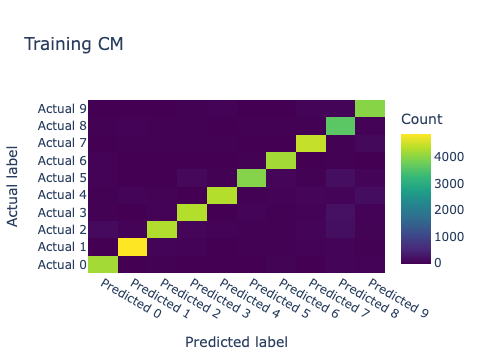

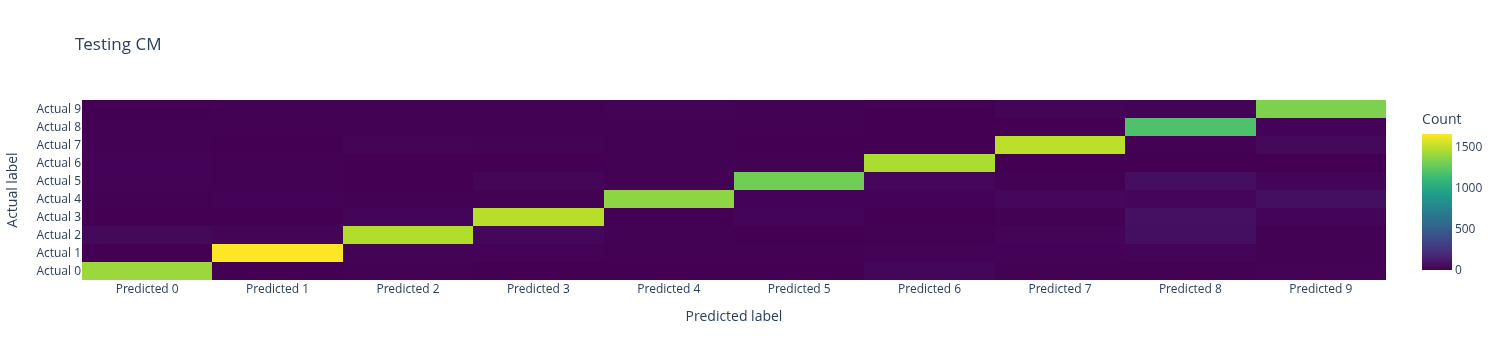

In [9]:
from sklearn.metrics import confusion_matrix
def build_confusion(predictions,truth,title):
    cm=confusion_matrix(predictions,truth)
    import plotly.graph_objects as go
    # Create a Plotly heatmap
    fig = go.Figure(data=go.Heatmap(
        z=cm,
        x=[f'Predicted {i}' for i in range(cm.shape[0])],
        y=[f'Actual {i}' for i in range(cm.shape[0])],
        colorscale='Viridis',  # You can choose any colorscale you like
        colorbar=dict(title='Count')
    ))
    
    # Update layout
    fig.update_layout(
        title=title,
        xaxis_title='Predicted label',
        yaxis_title='Actual label',
    )
    
    # Show plot
    fig.show()
model.eval()
with torch.no_grad():
    trainPred=np.argmax(model(Xtr.to(device)).detach().cpu().numpy(),axis=1)
    trainTruth=ytr.cpu().numpy()
    build_confusion(trainPred,trainTruth,'Training CM')
    testPred=np.argmax(model(Xte.to(device)).detach().cpu().numpy(),axis=1)
    testTruth=yte.cpu().numpy()
    build_confusion(testPred,testTruth,'Testing CM')

## Deep Convnet

As an example of a larger network, here's the summary of AlexNet, one of the most influential and famous models in ML, and one of the first to be trained on GPUs, allowing for many more parameters.  The ImageNet competition is an annual competition to build the classifier that could best classify several million images into 1000 categories.  In 2012, AlexNet defeated the next-best entry by over 10% accuracy; everybody noticed, and the deep network boom began.  AlexNet has over 62 million learnable parameters.

```
AlexNet(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(11, 11), stride=(4, 4), padding=(2, 2))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(64, 192, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(192, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): Conv2d(384, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU(inplace=True)
    (10): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (avgpool): AdaptiveAvgPool2d(output_size=(6, 6))
  (classifier): Sequential(
    (0): Dropout(p=0.5, inplace=False)
    (1): Linear(in_features=9216, out_features=4096, bias=True)
    (2): ReLU(inplace=True)
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=4096, out_features=4096, bias=True)
    (5): ReLU(inplace=True)
    (6): Linear(in_features=4096, out_features=1000, bias=True)
  )
)
```
